### Data Preparation

In [2]:
# run this only for once
from sklearn.datasets import fetch_openml # only for downlaoding the dataset
import numpy as np

mnist = fetch_openml('mnist_784', version=1, parser='auto')

In [3]:
X = mnist.data.to_numpy()
y = mnist.target.to_numpy().astype(int)

X = X / 255.0

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# one-hot encoding of the labels
def to_one_hot(y, num_classes=10):
    one_hot = np.zeros((y.size, num_classes))
    one_hot[np.arange(y.size), y] = 1
    return one_hot

# Example usage:
y_train = to_one_hot(y_train)  # Shape (60000, 10)
y_test = to_one_hot(y_test)    # Shape (10000, 10)

#### Weights Initialization throug He initialization 

In [18]:
def initialize_parameters():
    np.random.seed(42)  
    W1 = np.random.randn(784, 128) * np.sqrt(2/784)  # He initialization 
    b1 = np.zeros((1, 128))                 
    W2 = np.random.randn(128, 64) * np.sqrt(2/128)   
    b2 = np.zeros((1, 64))                  
    W3 = np.random.randn(64, 10) * np.sqrt(2/64)     
    b3 = np.zeros((1, 10))                  
    return W1, b1, W2, b2, W3, b3


##### Forward Pass

In [19]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = np.dot(X, W1) + b1
    A1 = np.maximum(0, Z1)  # ReLU activation
    Z2 = np.dot(A1, W2) + b2
    A2 = np.maximum(0, Z2)  # ReLU activation
    Z3 = np.dot(A2, W3) + b3
    exp_scores = np.exp(Z3 - np.max(Z3, axis=1, keepdims=True))  # for numerical stability
    A3 = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)  # Softmax activation
    cache = {'X':X, 'Z1':Z1, 'A1':A1, 'Z2':Z2, 'A2':A2, 'Z3':Z3, 'A3':A3, 'W1':W1, 'b1':b1, 'W2':W2, 'b2':b2, 'W3':W3, 'b3':b3}
    return A3, cache

#### Loss Function

In [20]:
def loss_function(yhat, y):
    m = y.shape[0]
    # clip yhat to avoid log(0) which is undefined
    yhat = np.clip(yhat, 1e-15, 1 - 1e-15)
    log_likelihood = -np.log(yhat[range(m), np.argmax(y, axis=1)]) # shape (m,)
    loss = np.sum(log_likelihood) / m
    return loss

#### Backward Pass -- The important One

In [64]:
def backward_pass(cache, y):
    X  = cache['X']
    Z1 = cache['Z1'];  A1 = cache['A1']
    Z2 = cache['Z2'];  A2 = cache['A2']
    A3 = cache['A3']
    W1, b1, W2, b2, W3, b3 = cache['W1'], cache['b1'], cache['W2'], cache['b2'], cache['W3'], cache['b3']
    m = X.shape[0]

    # Layer 3
    dL_dZ3 = (A3 - y )/ m # shape (m, 10)
    dL_dW3 = A2.T @ dL_dZ3  # shape (64, 10)
    dL_db3 = np.sum(dL_dZ3, axis=0, keepdims=True)  # shape (1, 10)
    dL_dA2 = dL_dZ3 @ W3.T  # shape (m, 64)

    # Layer 2
    dL_dZ2 = dL_dA2 * (Z2 > 0)  # ReLU derivative
    dL_dW2 = A1.T @ dL_dZ2  # shape (128, 64)
    dL_db2 = np.sum(dL_dZ2, axis=0, keepdims=True)  # shape (1, 64)
    dL_dA1 = dL_dZ2 @ W2.T  # shape (m, 128)

    # Layer 1
    dL_dZ1 = (Z1 > 0) * dL_dA1  # shape (m, 128)
    dL_dW1 = X.T @ dL_dZ1  # shape (784, 128)
    dL_db1 = np.sum(dL_dZ1, axis=0, keepdims=True)  # shape (1, 128)

    return dL_dW1, dL_db1, dL_dW2, dL_db2, dL_dW3, dL_db3

#### Training Loop

In [63]:
def get_accuracy(y_pred, Y):
    predictions = np.argmax(y_pred, axis=1)   # index of highest prob 
    labels      = np.argmax(Y,  axis=1)   # index of true class
    return np.mean(predictions == labels)


def training(X_train, y_train, learning_rate=0.01, epochs=100, batch_size=256):
    W1, b1, W2, b2, W3, b3 = initialize_parameters()
    m = X_train.shape[0]

    history = {'loss': [], 'accuracy': []}

    for i in range(epochs):
        # shuffle the data in each epoch
        permutation = np.random.permutation(m)
        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]

        for j in range(0, m, batch_size):
            X_batch = X_train_shuffled[j:j+batch_size]
            y_batch = y_train_shuffled[j:j+batch_size]

            # Forward Pass
            y_pred, cache = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)

            # Backward Pass
            dL_dW1, dL_db1, dL_dW2, dL_db2, dL_dW3, dL_db3 = backward_pass(cache, y_batch)

            # Parameters Update
            W1 -= learning_rate * dL_dW1
            b1 -= learning_rate * dL_db1
            W2 -= learning_rate * dL_dW2
            b2 -= learning_rate * dL_db2
            W3 -= learning_rate * dL_dW3
            b3 -= learning_rate * dL_db3

        # Loss/accuracy after each epoch (on full training set)
        y_pred_all, _ = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
        loss = loss_function(y_pred_all, y_train)
        accuracy = get_accuracy(y_pred_all, y_train)

        history['loss'].append(loss)
        history['accuracy'].append(accuracy)

        if (i + 1) % 5 == 0:
            print(f"Epoch {i+1}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

    return (W1, b1, W2, b2, W3, b3, history)


### Actual Running

In [71]:
W1, b1, W2, b2, W3, b3, history = training(X_train, y_train, learning_rate=0.1, epochs=50, batch_size=128)


Epoch 5/50, Loss: 0.0909, Accuracy: 0.9738
Epoch 10/50, Loss: 0.0480, Accuracy: 0.9864
Epoch 15/50, Loss: 0.0283, Accuracy: 0.9927
Epoch 20/50, Loss: 0.0147, Accuracy: 0.9973
Epoch 25/50, Loss: 0.0088, Accuracy: 0.9991
Epoch 30/50, Loss: 0.0057, Accuracy: 0.9996
Epoch 35/50, Loss: 0.0036, Accuracy: 0.9999
Epoch 40/50, Loss: 0.0026, Accuracy: 1.0000
Epoch 45/50, Loss: 0.0020, Accuracy: 1.0000
Epoch 50/50, Loss: 0.0016, Accuracy: 1.0000


#### Evaluation on Test Set

In [72]:
y_pred, cache= forward_pass(X_test, W1, b1, W2, b2, W3, b3)
loss = loss_function(y_pred, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {get_accuracy(y_pred, y_test):.4f}")

Test Loss: 0.0853, Test Accuracy: 0.9799


### Visualization
- This code cell is Ai generated 

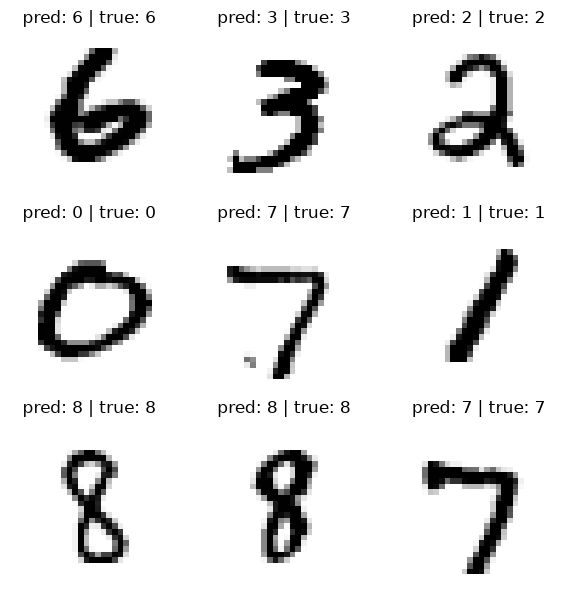

In [73]:
import matplotlib.pyplot as plt
import math

def show_predictions(X, y, W1, b1, W2, b2, W3, b3, num_images=9):
    # pick random samples
    idx = np.random.choice(X.shape[0], num_images, replace=False)
    Xs = X[idx]
    ys = y[idx]

    # forward pass for the selected samples
    probs, _ = forward_pass(Xs, W1, b1, W2, b2, W3, b3)
    preds = np.argmax(probs, axis=1)

    # handle one-hot or integer labels
    if ys.ndim > 1 and ys.shape[1] > 1:
        trues = np.argmax(ys, axis=1)
    else:
        trues = ys

    # grid layout
    cols = int(math.sqrt(num_images)) if int(math.sqrt(num_images))**2 == num_images else int(math.ceil(math.sqrt(num_images)))
    rows = int(math.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i, ax in enumerate(axes[:num_images]):
        img = Xs[i].reshape(28, 28)
        ax.imshow(img, cmap='gray_r')
        ax.set_title(f'pred: {preds[i]} | true: {trues[i]}')
        ax.axis('off')

    plt.tight_layout()

show_predictions(X_test, y_test, W1, b1, W2, b2, W3, b3, num_images=9)


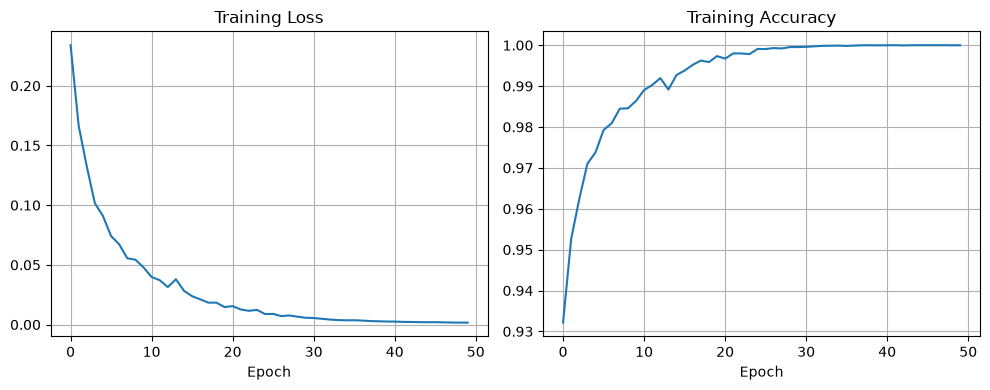

In [74]:
import matplotlib.pyplot as plt


def plot_history(history):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history['loss'], label='loss')
    plt.xlabel('Epoch')
    plt.title('Training Loss')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history['accuracy'], label='accuracy')
    plt.xlabel('Epoch')
    plt.title('Training Accuracy')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)
